# 04 — 第三代：Hybrid Pipeline + Data Recovery

**方法论定位（第三代，Nemotron-CC 2024）**

三个核心创新：
1. **分类器集成（Classifier Ensembling）**：多个分类器取并集，扩大高质量覆盖面
2. **条件性 Heuristic Bypass**：对高质量文档跳过 heuristic，减少误杀（Nemotron-CC 发现误杀率 18.1%）
3. **合成数据改写（Synthetic Rephrasing）**：低质量数据用 LLM API 改写后回收

**与第二代的核心区别**：
- 第二代丢弃 90% 数据（激进过滤）
- 第三代在质量不降的前提下保留约 38% 数据（4倍于第二代）
- Nemotron-CC：8B 模型 15T token 训练后超过 Llama 3.1 8B：MMLU +5, ARC-Challenge +3.1

> **本 notebook 读取预计算的 pipeline 结果进行可视化分析，不执行 pipeline 本身。**

## Cell Group A: 分类器集成（Classifier Ensembling）

> **为什么需要集成？单一分类器的盲区问题**
>
> 无论正样本是 OpenHermes（DCLM 风格）还是 Wikipedia（教育风格），
> 单一分类器都会有覆盖盲区。
> 例如：技术博客可能被“OpenHermes 风格”分类器低估，
> 却被“教育类”分类器高估。
>
> **Union 策略**：任一分类器认为高质量 → 判为高质量
> - 优点：扩大覆盖面，减少漏网之鱼
> - 缺点：可能引入更多噪声（对比 Intersection 策略）
>
> **Intersection 策略**：所有分类器都认为高质量
> - 类似第二代，更保守，质量更高但量更少
>
> Nemotron-CC 使用 Union 策略，实现了 +28% unique token 覆盖。

In [1]:
# === 加载配置和预计算结果（双档：smoke_test + full_run） ===
# 遍历两档 mode，加载 routing_summary 和 output docs，存入 dual 字典。
# 本 notebook 不执行 pipeline，只读取已有结果进行可视化分析。

import sys, json
sys.path.insert(0, '..')
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from src.utils.config_loader import load_run_config, get_output_path, print_config_summary

# --- 加载两档数据 ---
MODES = ['smoke_test', 'full_run']
MODE_LABELS = {'smoke_test': 'Smoke Test', 'full_run': 'Full Run'}
dual = {}

for mode in MODES:
    cfg = load_run_config(run_mode_override=mode)
    gen1_dir = get_output_path(1, cfg)
    gen3_dir = get_output_path(3, cfg)

    # 路由汇总
    summary_path = gen3_dir / 'gen3_routing_summary.json'
    with open(summary_path) as f:
        summary = json.load(f)

    # Gen3 输出文档
    gen3_path = gen3_dir / 'gen3_output.jsonl'
    gen3_docs = []
    with open(gen3_path) as f:
        for line in f:
            gen3_docs.append(json.loads(line))

    # Gen1 输出文档（Gen3 的输入）
    gen1_path = gen1_dir / 'gen1_output.jsonl'
    gen1_docs = []
    with open(gen1_path) as f:
        for line in f:
            gen1_docs.append(json.loads(line))

    ensemble_scores = np.array([d.get('_ensemble_score', 0) for d in gen3_docs])
    synthetic_count = sum(1 for d in gen3_docs if d.get('_synthetic'))

    dual[mode] = {
        'cfg': cfg,
        'summary': summary,
        'routing': summary['routing'],
        'bypass': summary['bypass_analysis'],
        'rephrase': summary['rephrasing'],
        'gen3_docs': gen3_docs,
        'gen1_docs': gen1_docs,
        'ensemble_scores': ensemble_scores,
        'synthetic_count': synthetic_count,
        'total_input': summary['routing']['total'],
    }
    print(f'[{MODE_LABELS[mode]}] 已加载: Gen1={len(gen1_docs):,} 条, Gen3={len(gen3_docs):,} 条, 路由汇总={summary_path.name}')

# --- 打印两档关键统计对比 ---
print('\n' + '=' * 60)
print('  双档数据统计对比')
print('=' * 60)
header = f'{"指标":<20} {"Smoke Test":>12} {"Full Run":>12}'
print(header)
print('-' * 46)

st, fr = dual['smoke_test'], dual['full_run']
rows = [
    ('Gen1 输入', len(st['gen1_docs']), len(fr['gen1_docs'])),
    ('Gen3 路由输入', st['total_input'], fr['total_input']),
    ('最终保留', st['routing']['total_kept'], fr['routing']['total_kept']),
    ('合成文档', st['synthetic_count'], fr['synthetic_count']),
]
for label, v1, v2 in rows:
    print(f'{label:<20} {v1:>12,} {v2:>12,}')

st_rate = st['routing']['total_kept'] / st['total_input']
fr_rate = fr['routing']['total_kept'] / fr['total_input']
print(f'{"保留率":<20} {st_rate:>11.1%} {fr_rate:>11.1%}')

# 保留 run_cfg 变量供后续兼容
run_cfg = dual['smoke_test']['cfg']

[Smoke Test] 已加载: Gen1=409 条, Gen3=78 条, 路由汇总=gen3_routing_summary.json
[Full Run] 已加载: Gen1=3,242 条, Gen3=60 条, 路由汇总=gen3_routing_summary.json

  双档数据统计对比
指标                     Smoke Test     Full Run
----------------------------------------------
Gen1 输入                       409        3,242
Gen3 路由输入                     409        3,242
最终保留                           17           60
合成文档                            0            0
保留率                         4.2%        1.9%


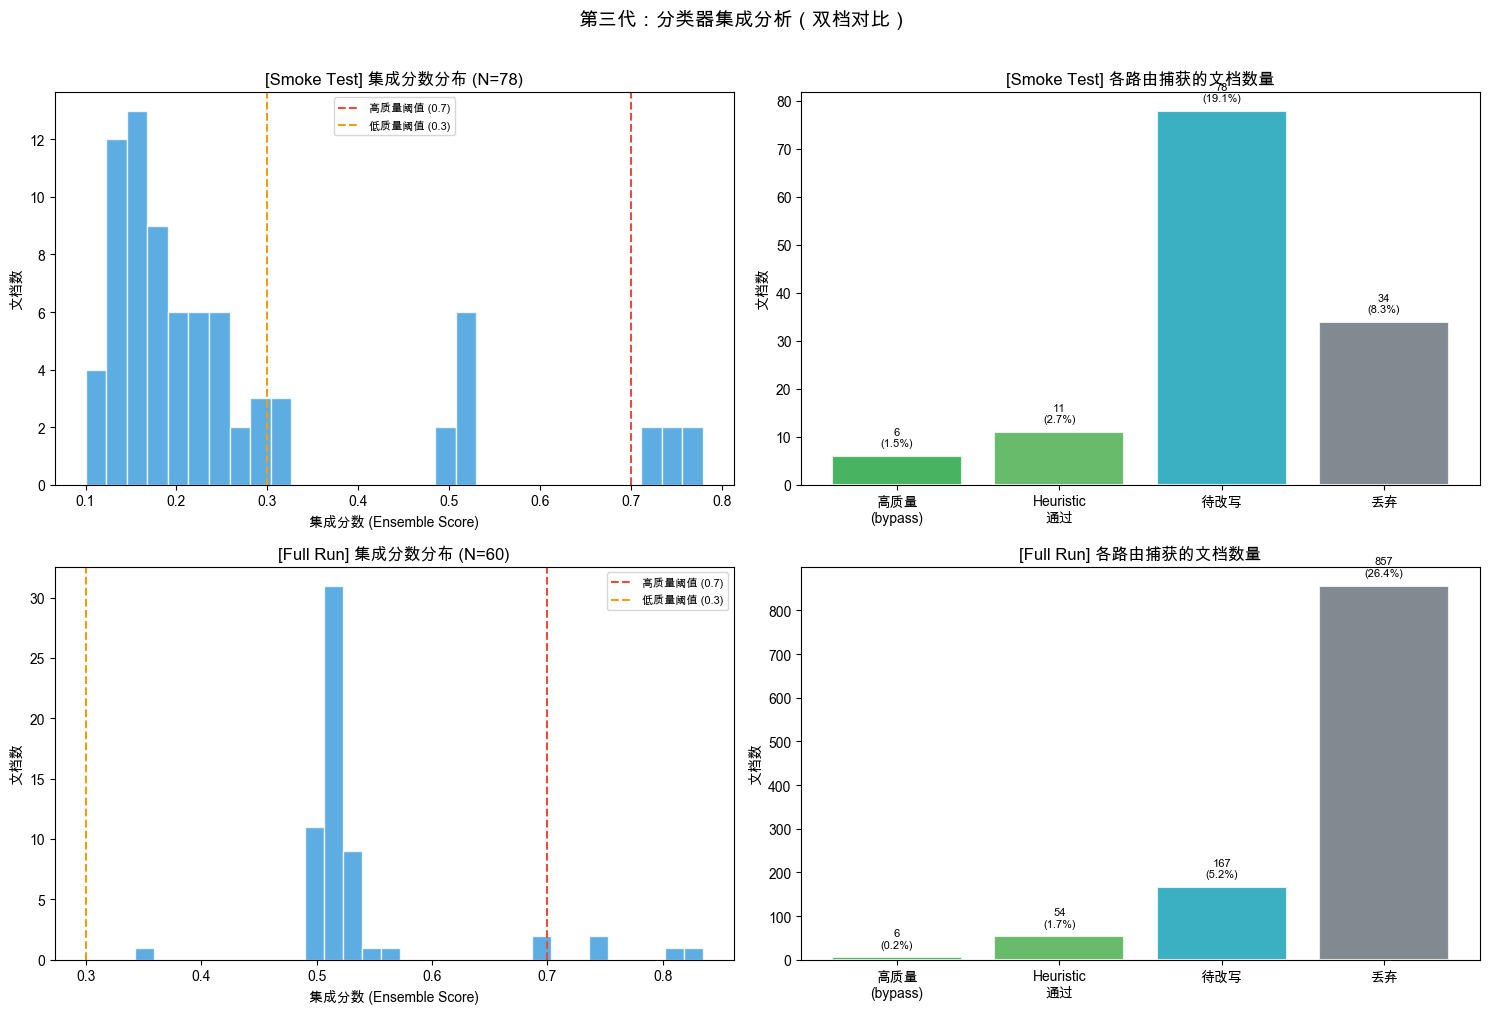

图表已保存: results/figures/04_gen3_ensemble_coverage.png


In [2]:
# === 集成覆盖率可视化（双档 2x2 布局） ===
# 上行：smoke_test 的分数分布 + 路由柱状图
# 下行：full_run 的分数分布 + 路由柱状图

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row_idx, mode in enumerate(MODES):
    d = dual[mode]
    routing = d['routing']
    total_input = d['total_input']
    scores = d['ensemble_scores']
    label = MODE_LABELS[mode]

    # -- 左列：集成分数分布 --
    ax_hist = axes[row_idx, 0]
    ax_hist.hist(scores, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
    ax_hist.axvline(x=0.7, color='#e74c3c', linestyle='--', linewidth=1.5, label='高质量阈值 (0.7)')
    ax_hist.axvline(x=0.3, color='#f39c12', linestyle='--', linewidth=1.5, label='低质量阈值 (0.3)')
    ax_hist.set_xlabel('集成分数 (Ensemble Score)')
    ax_hist.set_ylabel('文档数')
    ax_hist.set_title(f'[{label}] 集成分数分布 (N={len(scores):,})')
    ax_hist.legend(fontsize=8)

    # -- 右列：各路由捕获的文档数量 --
    ax_bar = axes[row_idx, 1]
    route_names = ['高质量\n(bypass)', 'Heuristic\n通过', '待改写', '丢弃']
    route_counts = [
        routing['high_quality']['count'],
        routing['heuristic_passed']['count'],
        routing['to_rephrase']['count'],
        routing['discarded']['count'],
    ]
    route_colors = ['#28a745', '#4CAF50', '#17a2b8', '#6c757d']

    bars = ax_bar.bar(route_names, route_counts, color=route_colors, alpha=0.85,
                       edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, route_counts):
        pct = count / total_input * 100 if total_input > 0 else 0
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(route_counts) * 0.02,
                    f'{count:,}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=8)
    ax_bar.set_ylabel('文档数')
    ax_bar.set_title(f'[{label}] 各路由捕获的文档数量')

plt.suptitle('第三代：分类器集成分析（双档对比）', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_ensemble_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_ensemble_coverage.png')

## Cell Group B: 条件性 Heuristic Bypass

> **核心问题：Heuristic 会误杀多少高质量文档？**
>
> Nemotron-CC 的关键发现：对 fastText 判定为高质量的文档，
> 如果再应用 heuristic filter，会误杀 **18.1% 的高质量 token**。
>
> **误杀的原因举例**：
> - 代码文档：含大量特殊字符 → 被 Gopher 的“alpha ratio”规则过滤
> - 技术教程：含代码片段（短行）→ 被 C4 的行规则过滤
> - 问答格式文本：平均句子短 → 被 Gopher 的 avg_sentence_length 过滤
>
> **解决方案（Bypass 路由）**：
> - score >= 0.7：直接保留（跳过 heuristic）
> - 0.3 <= score < 0.7：应用 heuristic
> - score < 0.3：送去 LLM 改写或丢弃

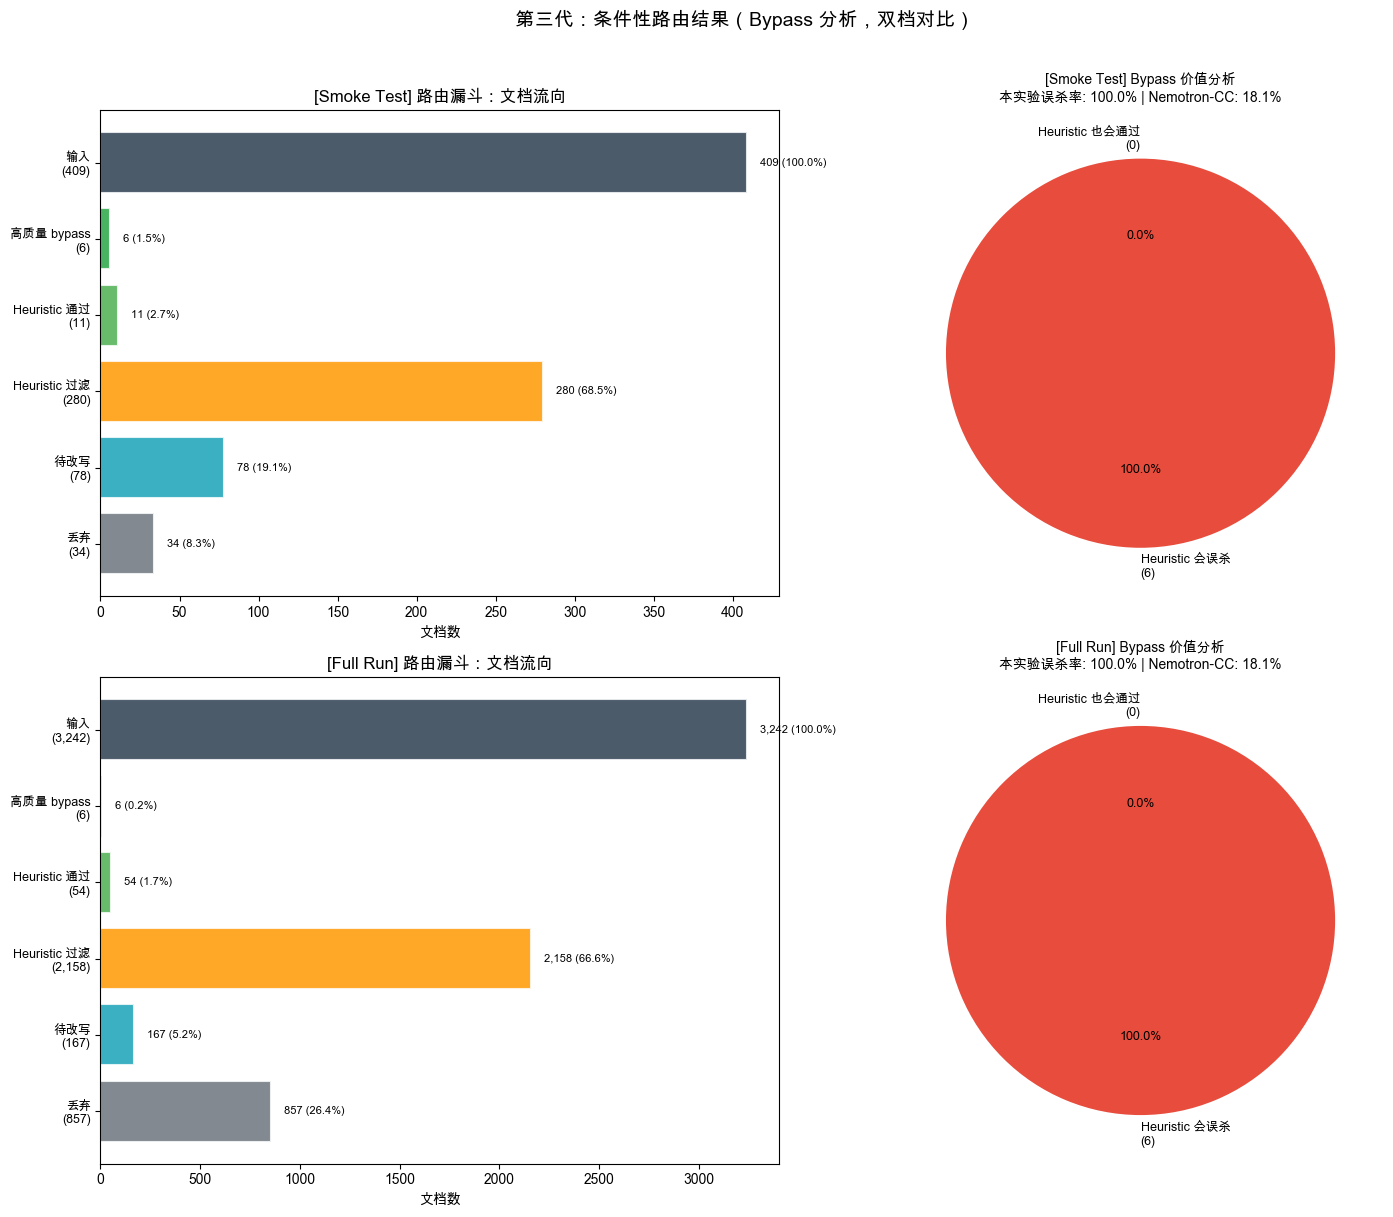

图表已保存: results/figures/04_gen3_routing.png


In [3]:
# === 条件性 Bypass 路由漏斗图（双档并排） ===
# 左列：路由漏斗（横向条形图），右列：Bypass 价值分析（饼图）
# 上行：smoke_test，下行：full_run

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for row_idx, mode in enumerate(MODES):
    d = dual[mode]
    routing = d['routing']
    bypass = d['bypass']
    total_input = d['total_input']
    label = MODE_LABELS[mode]

    hq = routing['high_quality']['count']
    hp = routing['heuristic_passed']['count']
    hf = routing['heuristic_filtered']['count']
    tr = routing['to_rephrase']['count']
    dc = routing['discarded']['count']

    # -- 左列：路由漏斗 --
    ax_funnel = axes[row_idx, 0]
    funnel_labels = [
        f'输入\n({total_input:,})',
        f'高质量 bypass\n({hq:,})',
        f'Heuristic 通过\n({hp:,})',
        f'Heuristic 过滤\n({hf:,})',
        f'待改写\n({tr:,})',
        f'丢弃\n({dc:,})',
    ]
    funnel_values = [total_input, hq, hp, hf, tr, dc]
    funnel_colors = ['#2c3e50', '#28a745', '#4CAF50', '#FF9800', '#17a2b8', '#6c757d']

    y_pos = range(len(funnel_labels))
    hbars = ax_funnel.barh(y_pos, funnel_values, color=funnel_colors, alpha=0.85,
                            edgecolor='white', linewidth=1.5)
    ax_funnel.set_yticks(list(y_pos))
    ax_funnel.set_yticklabels(funnel_labels, fontsize=9)
    ax_funnel.invert_yaxis()
    ax_funnel.set_xlabel('文档数')
    ax_funnel.set_title(f'[{label}] 路由漏斗：文档流向', fontweight='bold')
    for bar, val in zip(hbars, funnel_values):
        if val > 0:
            ax_funnel.text(bar.get_width() + max(funnel_values) * 0.02,
                           bar.get_y() + bar.get_height() / 2,
                           f'{val:,} ({val/total_input:.1%})',
                           va='center', fontsize=8)

    # -- 右列：Bypass 价值分析 --
    ax_pie = axes[row_idx, 1]
    hq_count = bypass['high_quality_count']
    filtered_count = bypass['would_be_filtered_count']
    filtered_rate = bypass['would_be_filtered_rate']
    saved_count = hq_count - filtered_count

    if hq_count > 0:
        if filtered_count > 0:
            wedge_sizes = [saved_count, filtered_count]
            wedge_labels = [
                f'Heuristic 也会通过\n({saved_count})',
                f'Heuristic 会误杀\n({filtered_count})',
            ]
            wedge_colors = ['#28a745', '#e74c3c']
        else:
            wedge_sizes = [hq_count]
            wedge_labels = [f'Heuristic 也会通过\n({hq_count})']
            wedge_colors = ['#28a745']
        ax_pie.pie(wedge_sizes, labels=wedge_labels, colors=wedge_colors,
                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
    else:
        ax_pie.text(0.5, 0.5, '无高质量 bypass 文档',
                    ha='center', va='center', fontsize=12, transform=ax_pie.transAxes)

    title_line2 = f'本实验误杀率: {filtered_rate:.1%} | Nemotron-CC: 18.1%'
    ax_pie.set_title(f'[{label}] Bypass 价值分析\n' + title_line2,
                      fontweight='bold', fontsize=10)

plt.suptitle('第三代：条件性路由结果（Bypass 分析，双档对比）', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/04_gen3_routing.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/04_gen3_routing.png')

## Cell Group C: 合成数据改写（Synthetic Rephrasing）

> **核心理念：低质量数据不是垃圾，而是待改写的原材料**
>
> Nemotron-CC 的洞见：通过 LLM API 将低质量文本改写为高质量文本，实现数据回收。
>
> **成本效益分析**：
> - Anthropic Haiku：约 $0.0003/千 token（输入）
> - 改写 300 条文档（full_run 配置）≈ 300 x 500 tokens = 150K tokens ≈ **$0.05**
> - 这 300 条变成高质量数据后，价值 >> 成本
>
> **改写后的质量验证**：
> 改写后的文档需要通过评估分类器验证（分数 >= 0.4 才保留），
> 避免“改写失败”（LLM 生成了更差的文本）的情况。

In [4]:
# === 改写统计（双档并排） ===
# 并排展示两档的 LLM 改写尝试/成功/失败统计

for mode in MODES:
    d = dual[mode]
    rephrase = d['rephrase']
    routing = d['routing']
    label = MODE_LABELS[mode]
    summary = d['summary']

    print('=' * 55)
    print(f'  [{label}] 合成数据改写 (Synthetic Rephrasing) 统计')
    print('=' * 55)

    if rephrase.get('skipped', False):
        print('  状态: 已跳过 (未配置 API Key 或无待改写文档)')
        rephrase_candidates = routing['to_rephrase']['count']
        print(f'  待改写候选: {rephrase_candidates:,} 条')
        print('  提示: 配置 configs/api_config.yaml 中的 api_key 可启用 LLM 改写')
    else:
        attempted = rephrase.get('attempted', 0)
        succeeded = rephrase.get('succeeded', 0)
        failed = rephrase.get('failed', 0)
        print(f'  尝试改写: {attempted:,} 条')
        print(f'  成功: {succeeded:,} 条')
        print(f'  失败: {failed:,} 条')
        if attempted > 0:
            print(f'  成功率: {succeeded/attempted:.1%}')
        print(f'  合成文档占最终输出: {d["synthetic_count"]:,} / {len(d["gen3_docs"]):,}')

    elapsed = summary.get('elapsed_seconds', 0)
    print(f'  Pipeline 执行时间: {elapsed:.2f} 秒')
    print()

  [Smoke Test] 合成数据改写 (Synthetic Rephrasing) 统计
  尝试改写: 0 条
  成功: 0 条
  失败: 17 条
  合成文档占最终输出: 0 / 78
  Pipeline 执行时间: 53.30 秒

  [Full Run] 合成数据改写 (Synthetic Rephrasing) 统计
  状态: 已跳过 (未配置 API Key 或无待改写文档)
  待改写候选: 167 条
  提示: 配置 configs/api_config.yaml 中的 api_key 可启用 LLM 改写
  Pipeline 执行时间: 4.31 秒



In [5]:
# === 第三代最终汇总（双档对比） ===
# 展示两档的路由明细和保留率对比

for mode in MODES:
    d = dual[mode]
    routing = d['routing']
    total_input = d['total_input']
    total_kept = routing['total_kept']
    retention_rate = total_kept / total_input if total_input > 0 else 0
    gen2_approx = int(total_input * 0.10)
    label = MODE_LABELS[mode]
    synthetic_count = d['synthetic_count']

    print('=' * 60)
    print(f'  [{label}] 第三代 Hybrid Pipeline -- 最终结论')
    print('=' * 60)
    print(f'  输入文档数: {total_input:,}')
    print(f'  最终输出: {total_kept:,} 条')
    hq_c = routing['high_quality']['count']
    hp_c = routing['heuristic_passed']['count']
    print(f'  |-- 高质量(bypass): {hq_c:,} 条')
    print(f'  |-- 中等(heuristic通过): {hp_c:,} 条')
    print(f'  +-- 合成数据(改写): {synthetic_count:,} 条')
    print(f'  总保留率: {retention_rate:.1%}')
    print()
    print('  对比第二代（top-10%）:')
    print(f'  第二代输出约: {gen2_approx:,} 条')
    print(f'  第三代输出约: {total_kept:,} 条')
    if gen2_approx > 0:
        print(f'  数据量倍数: {total_kept/gen2_approx:.1f}x')
    print()

    # 路由明细表
    header_route = '路由'
    header_count = '文档数'
    header_pct = '占比'
    print(f'  路由明细表：')
    print(f'  {header_route:<20} {header_count:>8} {header_pct:>8}')
    print('  ' + '-' * 38)
    for name, key in [('高质量 bypass', 'high_quality'),
                       ('Heuristic 通过', 'heuristic_passed'),
                       ('Heuristic 过滤', 'heuristic_filtered'),
                       ('待改写', 'to_rephrase'),
                       ('丢弃', 'discarded')]:
        c = routing[key]['count']
        r = routing[key]['rate']
        print(f'  {name:<20} {c:>8,} {r:>8.1%}')
    print('  ' + '-' * 38)
    footer_label = '最终保留'
    print(f'  {footer_label:<20} {total_kept:>8,} {retention_rate:>8.1%}')
    print()

# --- 双档保留率对比 ---
print('=' * 60)
print('  双档保留率对比')
print('=' * 60)
st_d = dual['smoke_test']
fr_d = dual['full_run']
st_rate = st_d['routing']['total_kept'] / st_d['total_input'] if st_d['total_input'] > 0 else 0
fr_rate = fr_d['routing']['total_kept'] / fr_d['total_input'] if fr_d['total_input'] > 0 else 0

compare_header = f'{"指标":<24} {"Smoke Test":>12} {"Full Run":>12}'
print(compare_header)
print('-' * 50)
compare_rows = [
    ('输入文档', st_d['total_input'], fr_d['total_input']),
    ('高质量 bypass', st_d['routing']['high_quality']['count'], fr_d['routing']['high_quality']['count']),
    ('Heuristic 通过', st_d['routing']['heuristic_passed']['count'], fr_d['routing']['heuristic_passed']['count']),
    ('合成数据', st_d['synthetic_count'], fr_d['synthetic_count']),
    ('最终保留', st_d['routing']['total_kept'], fr_d['routing']['total_kept']),
]
for label, v1, v2 in compare_rows:
    print(f'{label:<24} {v1:>12,} {v2:>12,}')
print(f'{"保留率":<24} {st_rate:>11.1%} {fr_rate:>11.1%}')
print()
print('  下一步 -> Notebook 05：去重分析')

  [Smoke Test] 第三代 Hybrid Pipeline -- 最终结论
  输入文档数: 409
  最终输出: 17 条
  |-- 高质量(bypass): 6 条
  |-- 中等(heuristic通过): 11 条
  +-- 合成数据(改写): 0 条
  总保留率: 4.2%

  对比第二代（top-10%）:
  第二代输出约: 40 条
  第三代输出约: 17 条
  数据量倍数: 0.4x

  路由明细表：
  路由                        文档数       占比
  --------------------------------------
  高质量 bypass                  6     1.5%
  Heuristic 通过               11     2.7%
  Heuristic 过滤              280    68.5%
  待改写                        78    19.1%
  丢弃                         34     8.3%
  --------------------------------------
  最终保留                       17     4.2%

  [Full Run] 第三代 Hybrid Pipeline -- 最终结论
  输入文档数: 3,242
  最终输出: 60 条
  |-- 高质量(bypass): 6 条
  |-- 中等(heuristic通过): 54 条
  +-- 合成数据(改写): 0 条
  总保留率: 1.9%

  对比第二代（top-10%）:
  第二代输出约: 324 条
  第三代输出约: 60 条
  数据量倍数: 0.2x

  路由明细表：
  路由                        文档数       占比
  --------------------------------------
  高质量 bypass                  6     0.2%
  Heuristic 通过               54     1.7%
  Heuristic 过